✅ Loading saved model...


Saving dog.jpg to dog.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


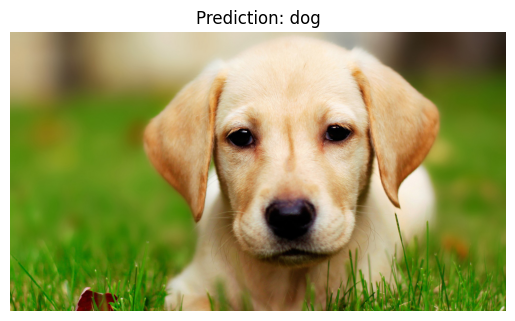

Predicted Class: dog


In [2]:
# -----------------------------
# Step 0: Install Libraries
# -----------------------------
!pip install tensorflow opencv-python matplotlib pillow

# -----------------------------
# Step 1: Imports
# -----------------------------
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

MODEL_PATH = "cifar10_model.h5"

# -----------------------------
# Step 2: Class Names
# -----------------------------
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# -----------------------------
# Step 3: Load or Train Model
# -----------------------------
if os.path.exists(MODEL_PATH):
    print("✅ Loading saved model...")
    model = load_model(MODEL_PATH)

else:
    print("🚀 Training model (first time only)...")

    # -----------------------------
    # Load Dataset
    # -----------------------------
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

    # Normalize
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    # -----------------------------
    # Build Model (Resize INSIDE)
    # -----------------------------
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Resizing(224, 224),  # ✅ avoids RAM crash
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    # -----------------------------
    # Train with batch (safe)
    # -----------------------------
    model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=32,
        validation_data=(x_test, y_test)
    )

    # -----------------------------
    # Save Model
    # -----------------------------
    model.save(MODEL_PATH)
    print("✅ Model saved!")

# -----------------------------
# Step 4: Upload Image
# -----------------------------
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# -----------------------------
# Step 5: Prediction
# -----------------------------
def predict_image(path):
    img = cv2.imread(path)
    img_resized = cv2.resize(img, (32, 32))  # original CIFAR size
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    prediction = model.predict(img_input)
    class_index = np.argmax(prediction)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {class_names[class_index]}")
    plt.axis('off')
    plt.show()

    print("Predicted Class:", class_names[class_index])

# -----------------------------
# Step 6: Run Prediction
# -----------------------------
predict_image(image_path)